In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 80, 3, padding=1, groups=20),
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 80, 1),   # pointwise conv
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 60, 3, padding=1, groups=20),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model28_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model28_0)
describe(model28_0)

MACs: 6.71 MMac, Params: 38.29 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model28_0.pt
Starting
Epoch 1/60: Train loss = 1.2927, Train accuracy = 0.5403, Test loss = 1.2192, Test accuracy = 0.5584
Epoch 2/60: Train loss = 0.9110, Train accuracy = 0.6784, Test loss = 0.8968, Test accuracy = 0.6844
Epoch 3/60: Train loss = 0.9264, Train accuracy = 0.6761, Test loss = 0.9270, Test accuracy = 0.6786
Epoch 4/60: Train loss = 0.7488, Train accuracy = 0.7402, Test loss = 0.7498, Test accuracy = 0.7406
Epoch 5/60: Train loss = 0.7108, Train accuracy = 0.7501, Test loss = 0.7170, Test accuracy = 0.7526
Epoch 6/60: Train loss = 0.6957, Train accuracy = 0.7576, Test loss = 0.6939, Test accuracy = 0.7583
Epoch 7/60: Train loss = 0.7132, Train accuracy = 0.7502, Test loss = 0.7236, Test accuracy = 0.7462
Epoch 8/60: Train loss = 0.6533, Train accuracy = 0.7702, Test loss = 0.6517, Test accuracy = 0.7728
Epoch 9/60: Train loss = 0.6149, Train accuracy = 0.7846, Test loss = 0.6430, Test accuracy = 0.7766
Epoch 10/60: Train loss = 0.579

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 54/60: Train loss = 0.2796, Train accuracy = 0.9023, Test loss = 0.3900, Test accuracy = 0.8692
Epoch 55/60: Train loss = 0.2769, Train accuracy = 0.9012, Test loss = 0.3884, Test accuracy = 0.8705
Epoch 56/60: Train loss = 0.2743, Train accuracy = 0.9035, Test loss = 0.3867, Test accuracy = 0.8700
Epoch 57/60: Train loss = 0.2754, Train accuracy = 0.9040, Test loss = 0.3880, Test accuracy = 0.8706
Epoch 58/60: Train loss = 0.2786, Train accuracy = 0.9019, Test loss = 0.3904, Test accuracy = 0.8706
Epoch 59/60: Train loss = 0.2766, Train accuracy = 0.9039, Test loss = 0.3875, Test accuracy = 0.8704
Epoch 60/60: Train loss = 0.2759, Train accuracy = 0.9023, Test loss = 0.3868, Test accuracy = 0.8695
Training complete.


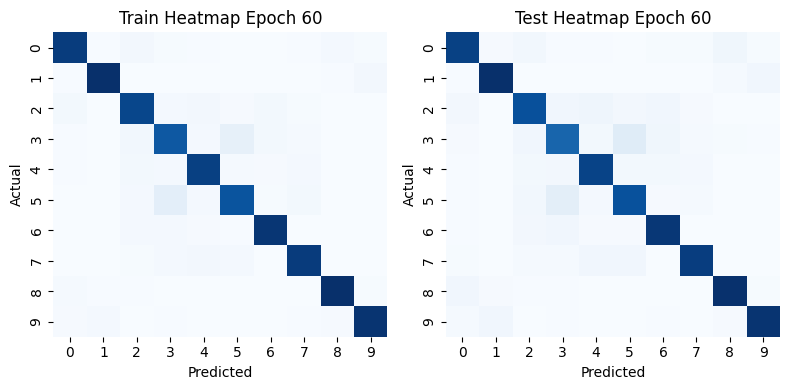

<Figure size 1200x600 with 0 Axes>

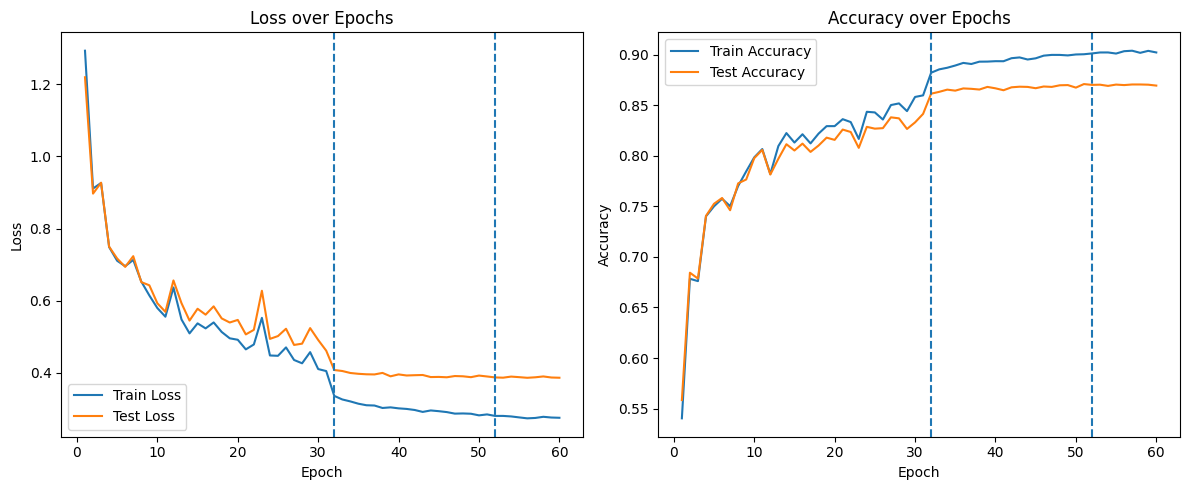

In [6]:
trainf32(model28_0,"model_weights/model28_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model28_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model28_1)
describe(model28_1)

MACs: 6.71 MMac, Params: 38.29 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.2263, Train accuracy = 0.5660, Test loss = 1.2400, Test accuracy = 0.5737
Epoch 2/60: Train loss = 1.0989, Train accuracy = 0.6284, Test loss = 1.1263, Test accuracy = 0.6250
Epoch 3/60: Train loss = 0.7990, Train accuracy = 0.7202, Test loss = 0.7831, Test accuracy = 0.7247
Epoch 4/60: Train loss = 0.7119, Train accuracy = 0.7511, Test loss = 0.7312, Test accuracy = 0.7504
Epoch 5/60: Train loss = 0.6470, Train accuracy = 0.7732, Test loss = 0.6804, Test accuracy = 0.7668
Epoch 6/60: Train loss = 0.6249, Train accuracy = 0.7832, Test loss = 0.6331, Test accuracy = 0.7782
Epoch 7/60: Train loss = 0.6667, Train accuracy = 0.7758, Test loss = 0.7183, Test accuracy = 0.7678
Epoch 8/60: Train loss = 0.6244, Train accuracy = 0.7825, Test loss = 0.6593, Test accuracy = 0.7723
Epoch 9/60: Train loss = 0.5819, Train accuracy = 0.8001, Test loss = 0.6330, Test accuracy = 0.7897
Epoch 10/60: Train loss = 0.5717, Train accuracy = 0.8017, Test loss = 0.5959, Test accurac

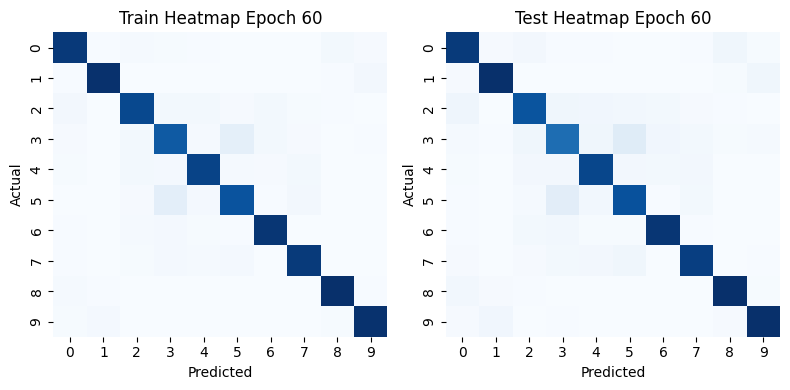

<Figure size 1200x600 with 0 Axes>

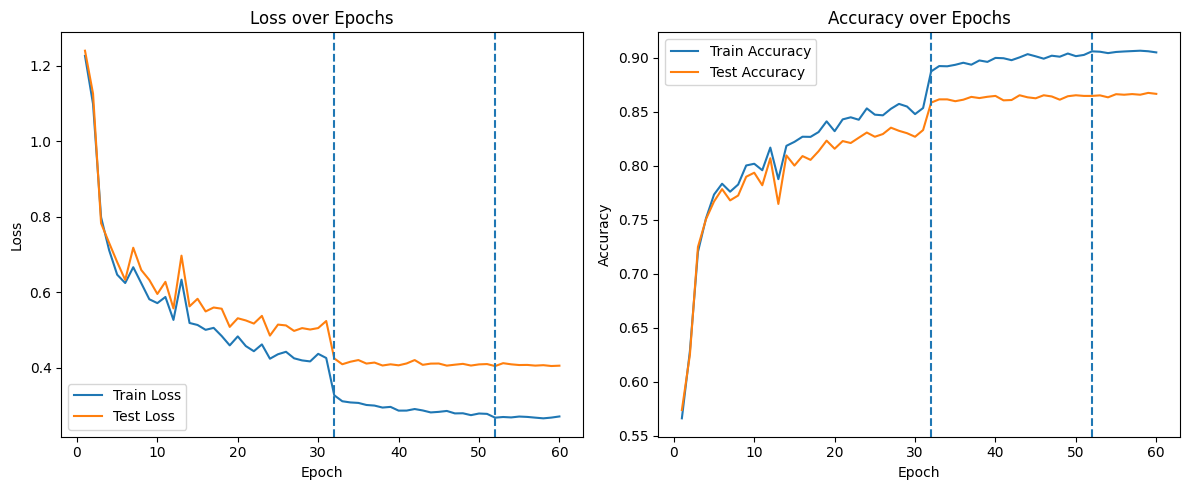

In [8]:
trainf32(model28_1,"model_weights/model28_1.pt",criterion,train_dataset,val_dataset, batch_size=64)